In [22]:
import pandas as pd
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df= pd.read_csv(url)

print(df.shape)
print(df.head(5))
print(df.dtypes)

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [23]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [24]:
# Looking at the data.

print(df['TotalCharges'].unique()[:20])

# Converting to float and blanks to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

#Checking for null values again 
print(df['TotalCharges'].isnull().sum())
print(df['TotalCharges'].dtypes)

<ArrowStringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',  '587.45',   '326.8',  '5681.1',  '5036.3',
 '2686.05', '7895.15', '1022.95', '7382.25',  '528.35',  '1862.9']
Length: 20, dtype: str
11
float64


In [25]:
df = df.dropna(subset=['TotalCharges'])
print(df.shape)

(7032, 21)


In [26]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3)*100)

Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn
No     73.4
Yes    26.6
Name: proportion, dtype: float64


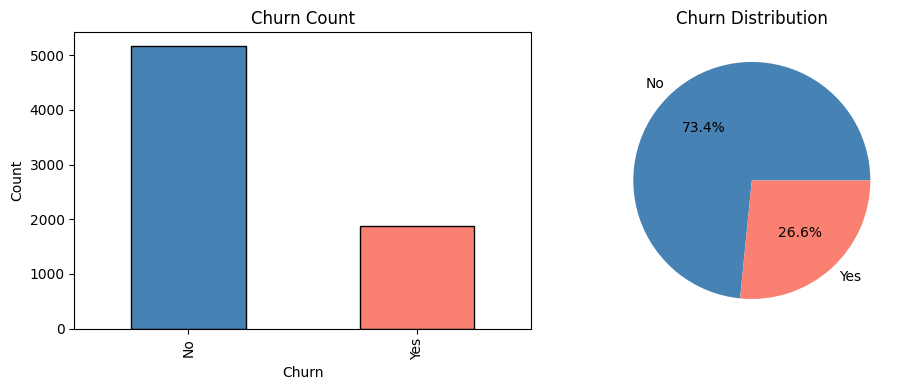

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1,2, figsize = (10,4))

df['Churn'].value_counts().plot(kind='bar', ax=axes[0],color = ['steelblue','salmon'],edgecolor = 'black')

axes[0].set_title('Churn Count')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')

df['Churn'].value_counts().plot(kind ='pie', ax=axes[1],autopct ='%1.1f%%',colors = ['steelblue','salmon'])

axes[1].set_title('Churn Distribution')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

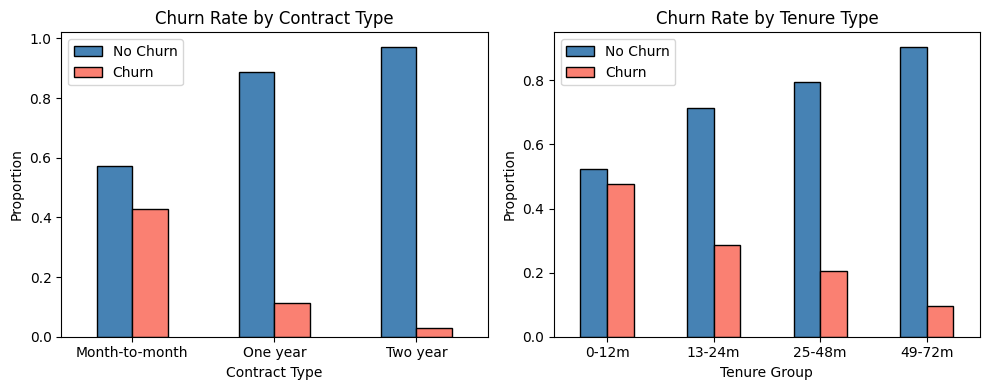

In [28]:
fig , axes =plt.subplots(1,2,figsize = (10,4))

contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
contract_churn.plot(kind = 'bar',ax = axes[0], color = ['steelblue','salmon'], edgecolor = 'black')
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Proportion')
axes[0].tick_params(axis = 'x', rotation = 0)
axes[0].legend(['No Churn','Churn'])

df['tenure_group'] = pd.cut(df['tenure'], bins = [0,12,24,48,72], labels =['0-12m','13-24m','25-48m','49-72m'])

tenure_churn = df.groupby('tenure_group')['Churn'].value_counts(normalize=True).unstack()
tenure_churn.plot(kind = 'bar',ax = axes[1], color = ['steelblue','salmon'], edgecolor = 'black')
axes[1].set_title('Churn Rate by Tenure Type')
axes[1].set_xlabel('Tenure Group')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis = 'x', rotation = 0)
axes[1].legend(['No Churn','Churn'])

plt.tight_layout()
plt.show()

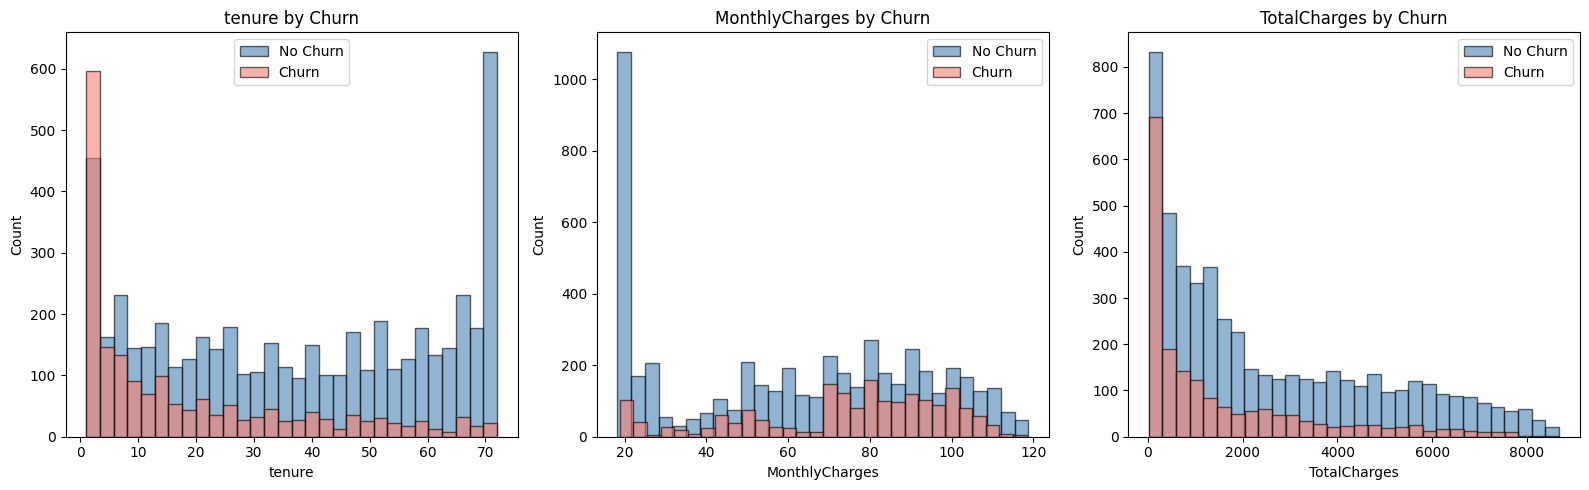

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
colors = {'No': 'steelblue', 'Yes': 'salmon'}

for i, col in enumerate(numeric_cols):
    for churn_val, color in colors.items():
        subset = df[df['Churn'] == churn_val][col]
        axes[i].hist(subset, bins=30, alpha=0.6, 
                     color=color, label=churn_val, edgecolor='black')
    axes[i].set_title(f'{col} by Churn')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

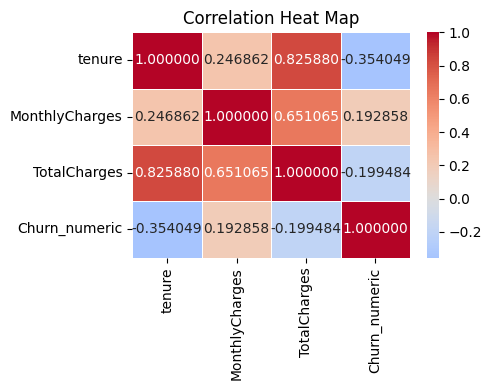

In [30]:
df['Churn_numeric'] = df['Churn'].map({'Yes':1,'No':0})

plt.figure(figsize=(5,4))
corr_cols = ['tenure','MonthlyCharges','TotalCharges','Churn_numeric']
sns.heatmap(df[corr_cols].corr(),annot =True,fmt ='2f', cmap = 'coolwarm', center = 0, linewidths=0.5)

plt.title('Correlation Heat Map')
plt.tight_layout()
plt.show()

In [31]:
## Feature Engineering 

cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)
print(f"Total Categorical colums:{len(cat_cols)}")

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
Total Categorical colums:17


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_34212\1106386205.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [32]:
df.head(15)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,Churn_numeric
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12m,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,25-48m,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12m,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48m,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12m,1
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,0-12m,1
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No,13-24m,0
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,Month-to-month,No,Mailed check,29.75,301.90,No,0-12m,0
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,25-48m,1
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No,49-72m,0


In [33]:
for col in cat_cols:
    print(f"{col} → {df[col].nunique()} unique values: {df[col].unique()}")
cat_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()

customerID → 7032 unique values: <ArrowStringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7032, dtype: str
gender → 2 unique values: <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner → 2 unique values: <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents → 2 unique values: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService → 2 unique values: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines → 3 unique values: <ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService → 3 unique values: <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity → 3 unique values: <ArrowStringArray>
['No', 'Yes', 'No internet s

In [34]:
# Step 1 - Drop unnecessary columns
df = df.drop(columns=['customerID', 'TotalCharges', 'tenure_group', 'Churn_numeric'])

# Step 2 - Encode target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Step 3 - Label encode binary columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Step 4 - One-Hot encode multi-category columns
ohe_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)

# Step 5 - Add our feature engineered column
df['avg_monthly_charges'] = df['MonthlyCharges'] / (df['tenure'] + 1)

print(df.shape)
print(df.head())

(7032, 31)
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   PaperlessBilling  MonthlyCharges  Churn  MultipleLines_No phone service  \
0                 1           29.85      0                            True   
1                 0           56.95      0                           False   
2                 1           53.85      1                           False   
3                 0           42.30      0                            True   
4                 1           70.70      1                           False   

   ...  StreamingTV_No internet service  StreamingTV_Yes  \
0  ...                           

In [35]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test , y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42,stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


smote = SMOTE(random_state=42)

X_train_sm,y_train_sm = smote.fit_resample(X_train,y_train)

print(f"Before SMOTE:{y_train.value_counts().to_dict()}")
print(f"After SMOTE:{pd.Series(y_train_sm).value_counts().to_dict()}")

Before SMOTE:{0: 4130, 1: 1495}
After SMOTE:{0: 4130, 1: 4130}


==== Logistics Regression ==== 
              precision    recall  f1-score   support

           0       0.89      0.73      0.81      1033
           1       0.51      0.75      0.60       374

    accuracy                           0.74      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.74      0.75      1407

ROC-AUC:0.835


<function matplotlib.pyplot.title(label: 'str', fontdict: 'dict[str, Any] | None' = None, loc: "Literal['left', 'center', 'right'] | None" = None, pad: 'float | None' = None, *, y: 'float | None' = None, **kwargs) -> 'Text'>

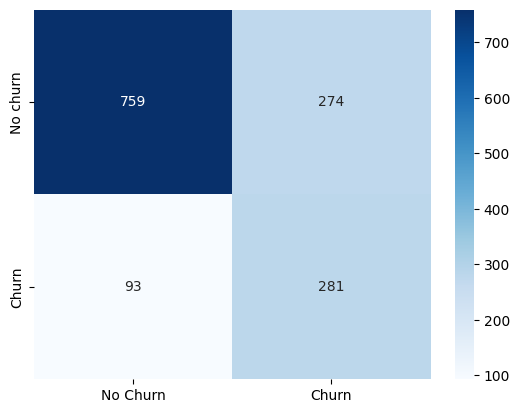

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns

lr = LogisticRegression(random_state=42,max_iter=100)
lr.fit(X_train_sm,y_train_sm)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

print("==== Logistics Regression ==== ")
print(classification_report(y_test,y_pred_lr))
print(f"ROC-AUC:{roc_auc_score(y_test,y_prob_lr):.3f}")


plt.Figure(figsize=(10,5))

sns.heatmap(confusion_matrix(y_test,y_pred_lr),annot=True, fmt='d',cmap='Blues', xticklabels=['No Churn','Churn'],yticklabels=['No churn','Churn'])
plt.title

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

rf_model = RandomForestClassifier(n_estimators=100, max_depth=None, min_samples_split=2, class_weight='balanced',random_state=42,n_jobs=1)

rf_model.fit(X_train_sm,y_train_sm)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("Random Forest")
print(classification_report(y_test,y_pred_rf))
print(f"ROC_AUC SCORE:{roc_auc_score(y_test,y_prob_rf):.3f}")

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1033
           1       0.57      0.59      0.58       374

    accuracy                           0.77      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.78      0.77      0.77      1407

ROC_AUC SCORE:0.821


In [38]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_sm, y_train_sm)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("==== XGBoost ====")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.3f}")

==== XGBoost ====
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1033
           1       0.57      0.67      0.61       374

    accuracy                           0.78      1407
   macro avg       0.72      0.74      0.73      1407
weighted avg       0.79      0.78      0.78      1407

ROC-AUC: 0.837


In [40]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_tuned = RandomizedSearchCV(
    estimator=XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_distributions,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    verbose=1
)

xgb_tuned.fit(X_train_sm, y_train_sm)

print("Best Parameters:", xgb_tuned.best_params_)
print("Best CV ROC-AUC:", xgb_tuned.best_score_.round(3))


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
Best CV ROC-AUC: 0.937


In [41]:
best_xgb = XGBClassifier(
    subsample=0.9,
    n_estimators=200,
    min_child_weight=1,
    max_depth=6,
    learning_rate=0.1,
    colsample_bytree=0.7,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(X_train_sm, y_train_sm)

y_pred_best = best_xgb.predict(X_test)
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]

print("==== XGBoost Tuned ====")
print(classification_report(y_test, y_pred_best))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_best):.3f}")

==== XGBoost Tuned ====
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407

ROC-AUC: 0.826


In [42]:
import joblib

joblib.dump(xgb_model, 'models/xgb_churn_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("Models saved successfully!")

FileNotFoundError: [Errno 2] No such file or directory: 'models/xgb_churn_model.pkl'

In [43]:
import os
import joblib

# Create folder if it doesn't exist
os.makedirs('models', exist_ok=True)

joblib.dump(xgb_model, 'models/xgb_churn_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("Models saved successfully!")



Models saved successfully!


c:\Users\Lenovo\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


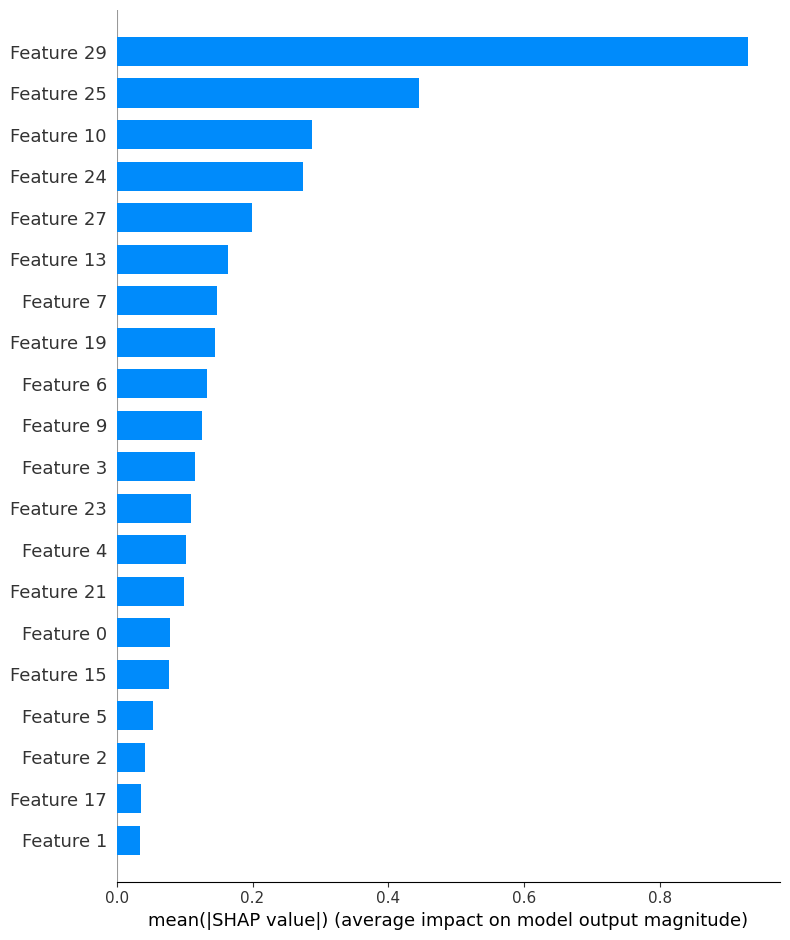

In [44]:
import shap
 
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values,X_test, plot_type = 'bar')

In [46]:
print(type(X_test))

<class 'numpy.ndarray'>


In [49]:
print(type(X_train))
print(type(X_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [50]:
print(X_train_sm.shape)
print(type(X_train_sm))

(8260, 30)
<class 'numpy.ndarray'>


In [51]:
# Get column names from original dataframe before SMOTE
print(df.drop(columns=['Churn']).columns.tolist())
print("Total columns:", len(df.drop(columns=['Churn']).columns))


['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'avg_monthly_charges']
Total columns: 30


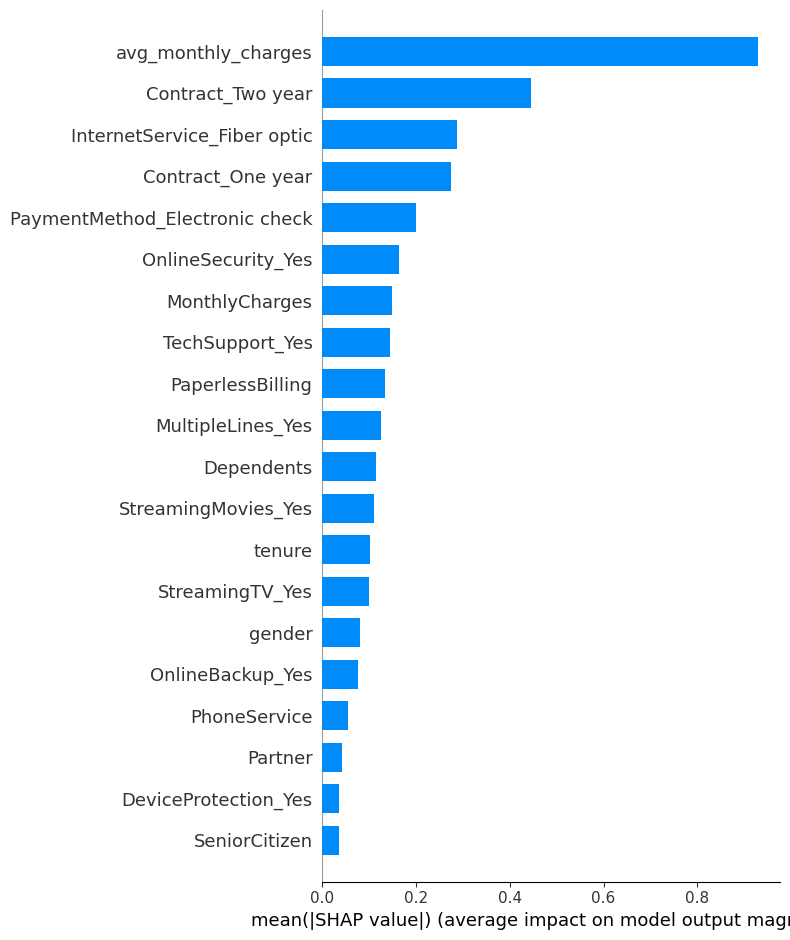

In [55]:
# Reconstruct X_test and X_train as DataFrames with proper column names
feature_names = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 
                 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 
                 'MultipleLines_No phone service', 'MultipleLines_Yes', 
                 'InternetService_Fiber optic', 'InternetService_No', 
                 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 
                 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 
                 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 
                 'TechSupport_No internet service', 'TechSupport_Yes', 
                 'StreamingTV_No internet service', 'StreamingTV_Yes', 
                 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 
                 'Contract_One year', 'Contract_Two year', 
                 'PaymentMethod_Credit card (automatic)', 
                 'PaymentMethod_Electronic check', 
                 'PaymentMethod_Mailed check', 'avg_monthly_charges']

# Rebuild as DataFrames
X_test_df = pd.DataFrame(X_test, columns=feature_names)
X_train_df = pd.DataFrame(X_train_sm, columns=feature_names)

# Recalculate SHAP values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_df)

# Bar plot — overall feature importance
shap.summary_plot(shap_values, X_test_df, plot_type="bar")

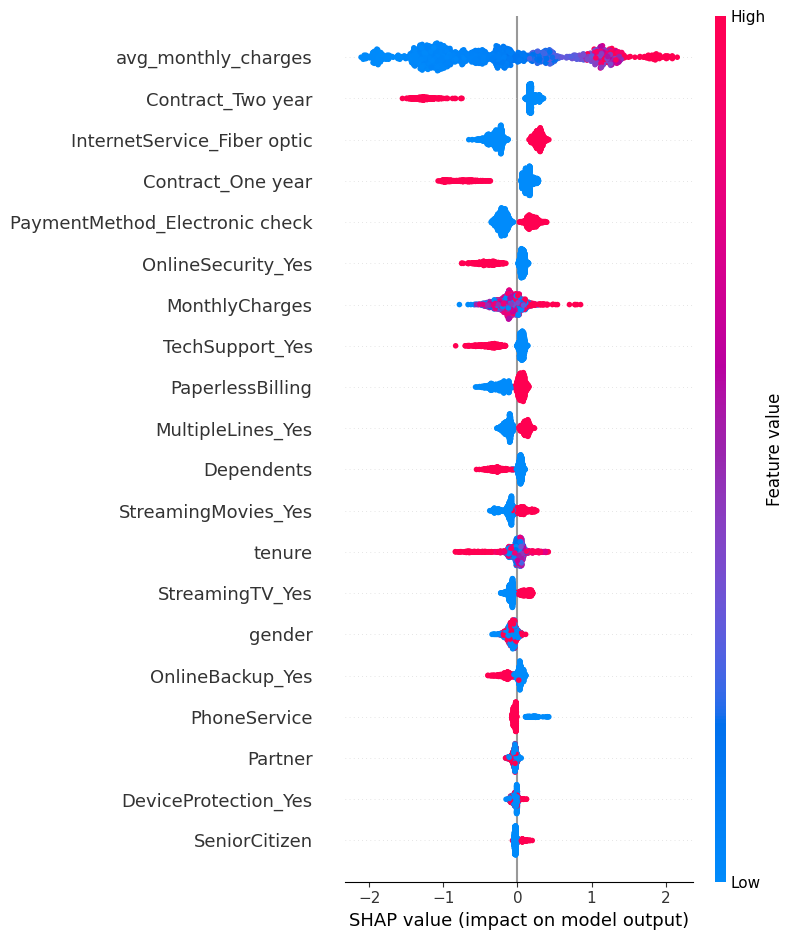

In [58]:
shap.summary_plot(shap_values, X_test_df)

In [59]:
# Explain a single customer prediction
shap.initjs()

# Pick a churned customer from test set
churn_idx = y_test[y_test == 1].index[0]
customer = X_test_df[y_test.values == 1][0:1]

shap.force_plot(
    explainer.expected_value,
    shap_values[y_test.values == 1][0],
    customer
)